<a href="https://colab.research.google.com/github/IrfanKpm/ai-with-huggingface/blob/main/ch02_audio_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Audio Processing

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [11]:
from google.colab import userdata

hf_token = userdata.get('HUGGING_FACE_API')

In [ ]:
audio = "/content/audio.mp3"

In [ ]:
y,sr = librosa.load(audio, sr=None)

In [ ]:
y[:50]

array([ 2.6488653e-04,  2.4975627e-04,  1.6459002e-04,  3.1632168e-05,
       -3.2147317e-04, -7.2078221e-04, -8.3144923e-04, -8.3678978e-04,
       -8.2083303e-04, -6.8522413e-04, -5.0709880e-04, -4.2628011e-04,
       -4.5403437e-04, -3.9708641e-04, -5.5321201e-04, -7.6125149e-04,
       -8.0002344e-04, -9.1192778e-04, -1.0607839e-03, -1.1640819e-03,
       -1.4524901e-03, -1.7727998e-03, -1.6521367e-03, -1.5449098e-03,
       -1.4915359e-03, -1.3297040e-03, -1.2325171e-03, -1.1390817e-03,
       -1.1987486e-03, -1.3695466e-03, -1.3949947e-03, -1.2926327e-03,
       -1.2079849e-03, -1.0160878e-03, -9.1167766e-04, -9.0395624e-04,
       -8.2677172e-04, -8.6404406e-04, -9.6385367e-04, -1.0440154e-03,
       -1.0523146e-03, -1.1070065e-03, -1.3047231e-03, -1.3912899e-03,
       -1.4088877e-03, -1.4882885e-03, -1.2060364e-03, -9.8441134e-04,
       -1.0800331e-03, -9.4483700e-04], dtype=float32)

In [ ]:
y.shape

(293280,)

In [ ]:
293280/16000  # duration (seconds) = number of samples / sample rate

18.33

In [ ]:
sr

16000

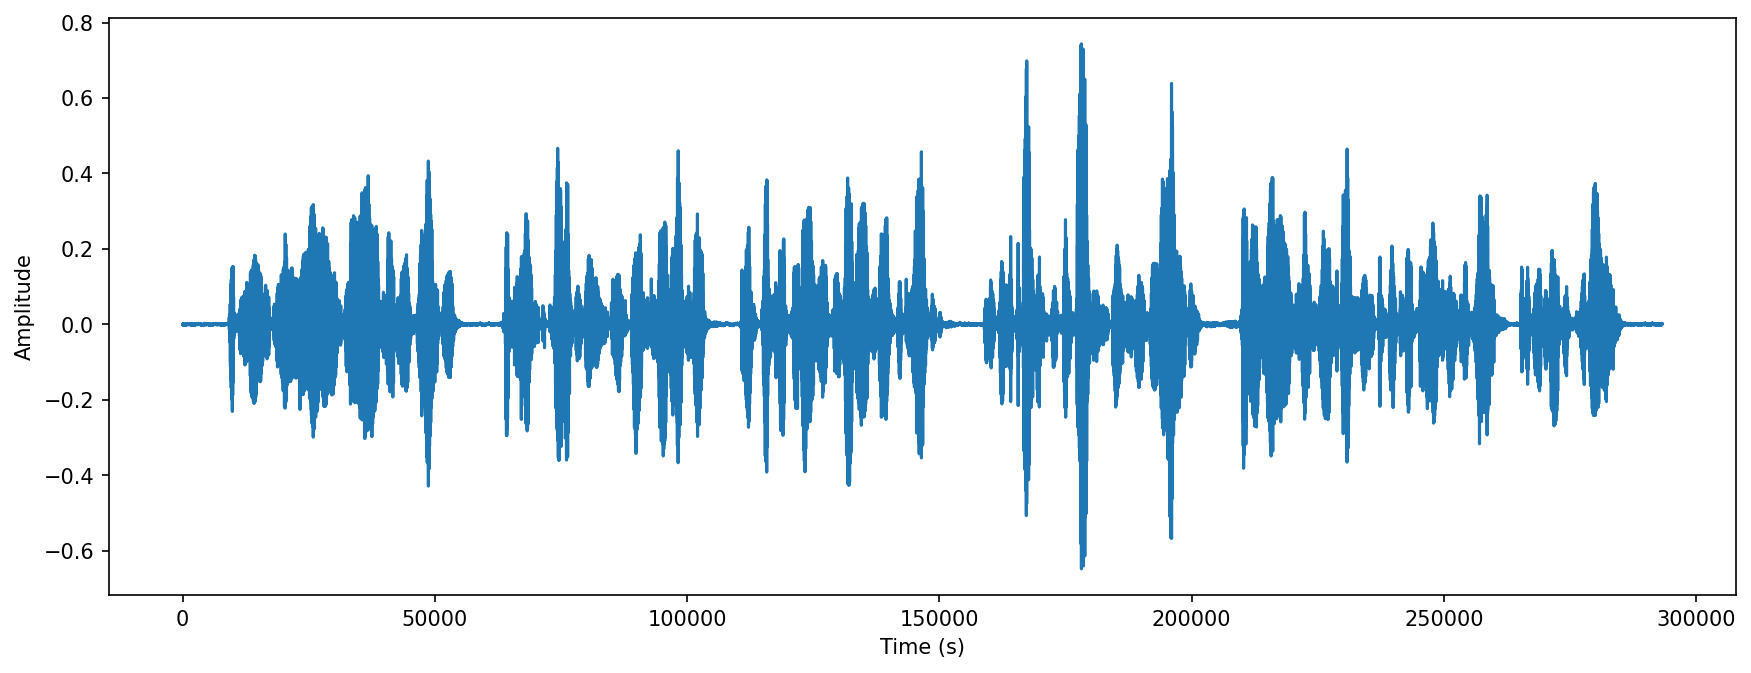

In [ ]:
plt.figure(figsize=(14,5),dpi=150)
plt.plot(y)
plt.xlabel("Time - Samples")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
from IPython.display import Audio

In [ ]:
Audio(data=y,rate=sr)

In [ ]:
# DFT (Discrete Fourier Transform)

window = np.hanning(len(y))
windowed_input = y * window

dft = np.fft.rfft(windowed_input)

In [ ]:
dft

array([-1.86261994e+01+0.00000000e+00j,  9.28135505e+00+1.32683733e-01j,
        1.58371706e-01-1.37403646e-02j, ...,
        5.96883425e-05+1.24873961e-04j, -4.06976410e-05-8.91529285e-05j,
        1.86791506e-05+0.00000000e+00j])

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


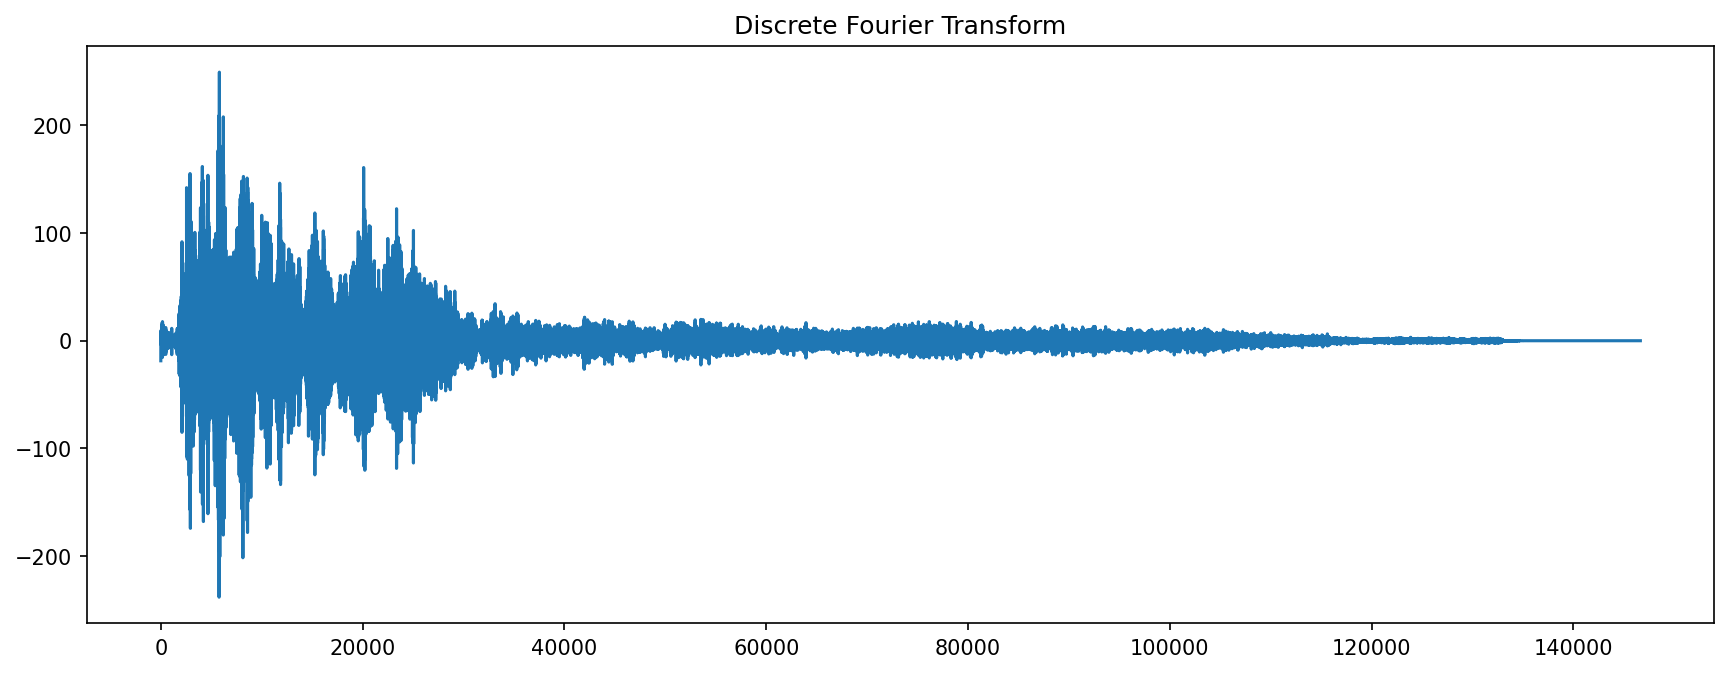

In [ ]:
plt.figure(figsize=(14,5),dpi=150)
plt.plot(dft)
plt.title("Discrete Fourier Transform")
plt.show()

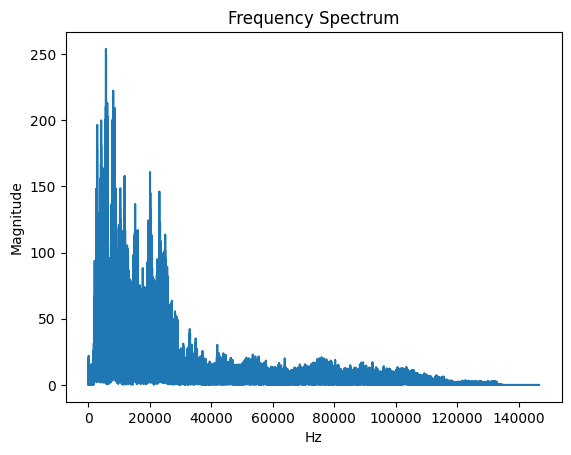

In [ ]:
plt.plot(np.abs(dft))
plt.title("Frequency Spectrum")
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

In [ ]:
D = librosa.stft(y)
D

array([[-3.9062458e-01+0.00000000e+00j, -4.2117184e-01+0.00000000e+00j,
         1.1969010e-02+0.00000000e+00j, ...,
        -6.5407574e-02+0.00000000e+00j, -6.5767783e-01+0.00000000e+00j,
        -5.0403225e-01+0.00000000e+00j],
       [ 2.1504030e-01-2.72883296e-01j,  3.9520788e-01+2.35286862e-01j,
        -1.8954851e-01+2.01399028e-01j, ...,
         3.1809140e-02-5.20105779e-01j,  4.7990891e-01-7.20481798e-02j,
         3.0529091e-01+2.31271148e-01j],
       [ 6.6572405e-02+2.29919523e-01j, -2.2219624e-01-2.22454607e-01j,
         1.7292516e-01-1.01863794e-01j, ...,
         1.0541111e-02+3.11359972e-01j, -1.3832895e-01-1.56319544e-01j,
        -1.7233564e-01-4.72149439e-02j],
       ...,
       [ 1.0714734e-04-5.60417561e-07j, -5.3679560e-05-5.20152668e-08j,
        -1.5320092e-07+3.75490657e-07j, ...,
         6.0672232e-07-2.05872041e-07j, -6.9409925e-06+3.98072962e-06j,
         1.9291588e-04-1.26878978e-04j],
       [-1.0707157e-04+5.65493735e-07j,  7.7784847e-07+5.36762345e-0

In [ ]:
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
D_db

array([[-44.236023, -43.58203 , -74.510056, ..., -59.758656, -39.710953,
        -42.02205 ],
       [-45.25387 , -42.817104, -47.235157, ..., -41.73317 , -42.351242,
        -44.407246],
       [-48.49006 , -46.12113 , -50.020393, ..., -46.200985, -49.67927 ,
        -51.02939 ],
       ...,
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], dtype=float32)

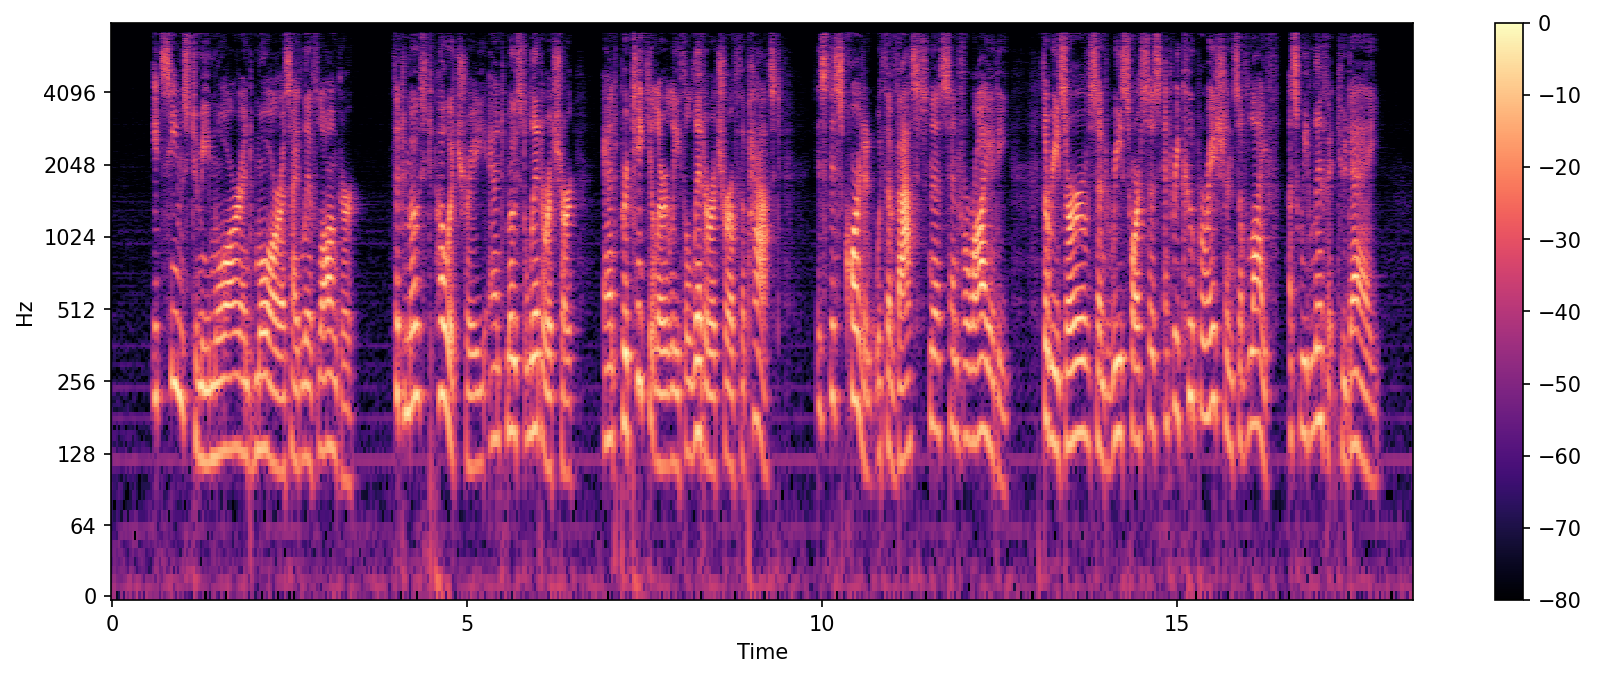

In [ ]:
plt.figure(figsize=(14,5),dpi=150)
librosa.display.specshow(D_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar()
plt.show()

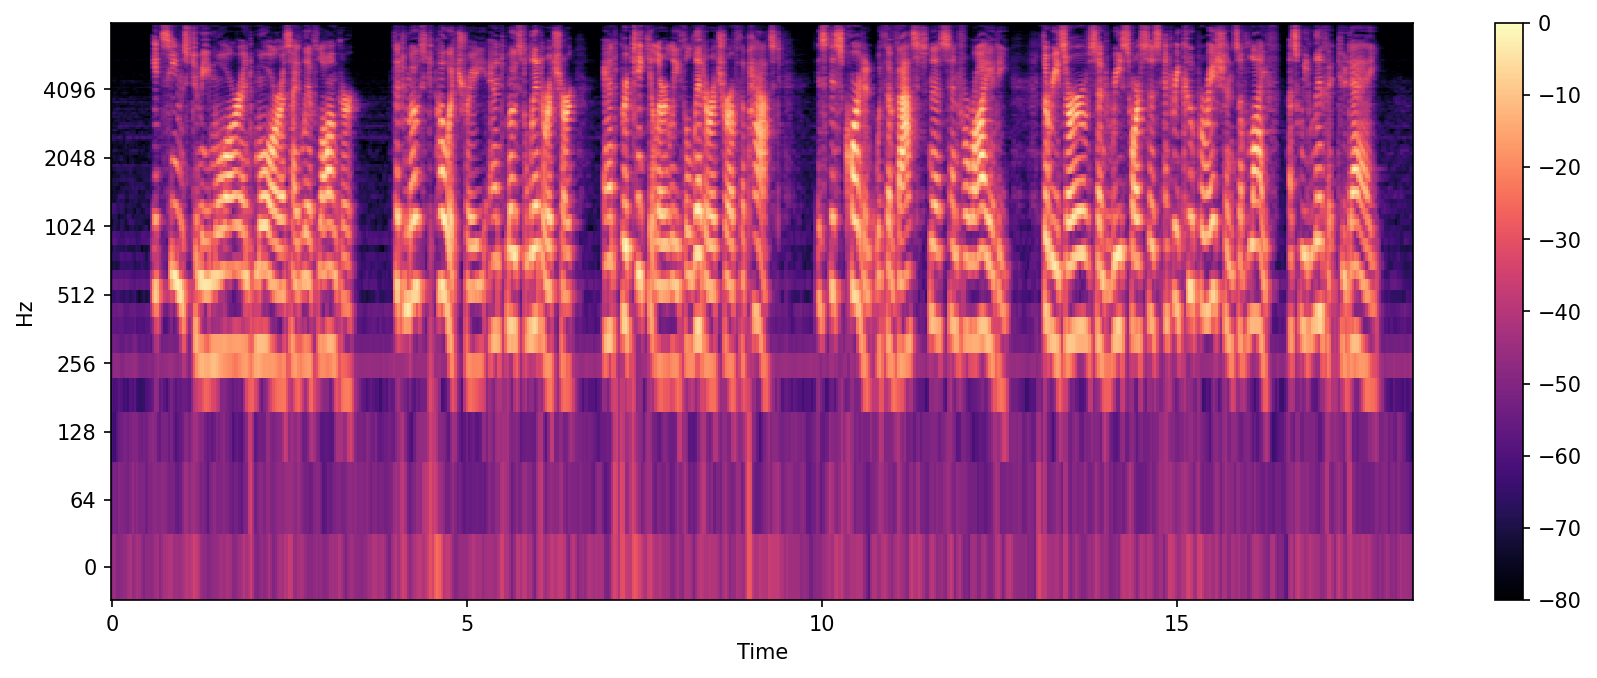

In [ ]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(14,5),dpi=150)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log',fmax=8000)
plt.colorbar()
plt.show()

In [1]:
import torch,transformers , torchaudio


In [ ]:
print(torch.__version__)
print(transformers.__version__)
print(torchaudio.__version__)

2.11.0+cpu
5.10.2
2.11.0+cpu


## Audio Classification

In [2]:
from transformers import AutoFeatureExtractor, ASTForAudioClassification

In [3]:
import librosa

In [6]:
audio = "/content/audio.mp3"

In [7]:
y,sr = librosa.load(audio,sr=None)

In [8]:
from IPython.display import Audio

Audio(data=y,rate=sr)

In [12]:
model_name = "MIT/ast-finetuned-audioset-10-10-0.4593"

feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
model = ASTForAudioClassification.from_pretrained(model_name,token=hf_token)

print(model.config.id2label)

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

{0: 'Speech', 1: 'Male speech, man speaking', 2: 'Female speech, woman speaking', 3: 'Child speech, kid speaking', 4: 'Conversation', 5: 'Narration, monologue', 6: 'Babbling', 7: 'Speech synthesizer', 8: 'Shout', 9: 'Bellow', 10: 'Whoop', 11: 'Yell', 12: 'Battle cry', 13: 'Children shouting', 14: 'Screaming', 15: 'Whispering', 16: 'Laughter', 17: 'Baby laughter', 18: 'Giggle', 19: 'Snicker', 20: 'Belly laugh', 21: 'Chuckle, chortle', 22: 'Crying, sobbing', 23: 'Baby cry, infant cry', 24: 'Whimper', 25: 'Wail, moan', 26: 'Sigh', 27: 'Singing', 28: 'Choir', 29: 'Yodeling', 30: 'Chant', 31: 'Mantra', 32: 'Male singing', 33: 'Female singing', 34: 'Child singing', 35: 'Synthetic singing', 36: 'Rapping', 37: 'Humming', 38: 'Groan', 39: 'Grunt', 40: 'Whistling', 41: 'Breathing', 42: 'Wheeze', 43: 'Snoring', 44: 'Gasp', 45: 'Pant', 46: 'Snort', 47: 'Cough', 48: 'Throat clearing', 49: 'Sneeze', 50: 'Sniff', 51: 'Run', 52: 'Shuffle', 53: 'Walk, footsteps', 54: 'Chewing, mastication', 55: 'Biting

In [13]:
result = feature_extractor(y,sampling_rate=sr,return_tensors="pt")

In [15]:
result['input_values']

tensor([[[-0.9916, -1.2776, -1.0232,  ..., -1.2776, -1.2776, -1.2776],
         [-0.9121, -1.2776, -0.9703,  ..., -1.2776, -1.2776, -1.2776],
         [-0.8493, -1.2776, -0.9493,  ..., -1.2776, -1.2776, -1.2776],
         ...,
         [-0.9670, -1.2510, -0.8742,  ..., -1.1290, -1.2776, -1.2776],
         [-0.7404, -1.1572, -0.7804,  ..., -1.0399, -1.2776, -1.2776],
         [-1.2306, -1.2776, -1.0361,  ..., -1.1105, -1.2776, -1.2776]]])

In [16]:
result['input_values'].shape

torch.Size([1, 1024, 128])

In [17]:
model = ASTForAudioClassification.from_pretrained(model_name)

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

In [18]:
model

ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ASTLayer(
        (attention): ASTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ASTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Li

In [19]:
prediction_logits = model(result['input_values'])

In [20]:
prediction_logits

SequenceClassifierOutput(loss=None, logits=tensor([[  1.7607,  -3.6278,  -5.1216,  -7.7976,  -4.6517,  -3.2460,  -9.5136,
          -3.6803, -10.1801,  -9.8109,  -9.2966, -10.5910, -12.0996, -11.3893,
         -10.0550,  -7.3453,  -8.1254,  -9.6309,  -9.5075,  -8.7204,  -9.9590,
          -7.4435,  -9.4690,  -9.6452,  -8.1356,  -9.9139,  -7.7653,  -9.1153,
         -11.2206, -11.5307, -10.7970,  -8.6758,  -9.5446, -10.2912, -10.9545,
         -12.5483,  -9.6943, -10.3114,  -9.3938, -10.0388,  -8.9070,  -5.2119,
          -7.9866,  -8.8267,  -4.6785,  -7.5004,  -6.4128,  -8.1301,  -6.1485,
          -7.9236,  -8.6372,  -8.1780,  -7.1531,  -7.5999,  -7.6198,  -7.0706,
         -10.8478,  -9.5550, -10.1405,  -8.3671,  -9.2930,  -7.4139,  -6.8052,
          -7.8090, -10.0894, -10.1416, -10.3179,  -9.5295, -11.4273,  -9.4677,
          -9.6600, -12.1333,  -5.2777,  -6.3861,  -7.1100,  -8.6033,  -9.1236,
         -11.6774,  -8.4648,  -9.2849,  -8.7651,  -6.6391,  -8.5326,  -7.7665,
         

In [23]:
logits = prediction_logits.logits
print(logits)

tensor([[  1.7607,  -3.6278,  -5.1216,  -7.7976,  -4.6517,  -3.2460,  -9.5136,
          -3.6803, -10.1801,  -9.8109,  -9.2966, -10.5910, -12.0996, -11.3893,
         -10.0550,  -7.3453,  -8.1254,  -9.6309,  -9.5075,  -8.7204,  -9.9590,
          -7.4435,  -9.4690,  -9.6452,  -8.1356,  -9.9139,  -7.7653,  -9.1153,
         -11.2206, -11.5307, -10.7970,  -8.6758,  -9.5446, -10.2912, -10.9545,
         -12.5483,  -9.6943, -10.3114,  -9.3938, -10.0388,  -8.9070,  -5.2119,
          -7.9866,  -8.8267,  -4.6785,  -7.5004,  -6.4128,  -8.1301,  -6.1485,
          -7.9236,  -8.6372,  -8.1780,  -7.1531,  -7.5999,  -7.6198,  -7.0706,
         -10.8478,  -9.5550, -10.1405,  -8.3671,  -9.2930,  -7.4139,  -6.8052,
          -7.8090, -10.0894, -10.1416, -10.3179,  -9.5295, -11.4273,  -9.4677,
          -9.6600, -12.1333,  -5.2777,  -6.3861,  -7.1100,  -8.6033,  -9.1236,
         -11.6774,  -8.4648,  -9.2849,  -8.7651,  -6.6391,  -8.5326,  -7.7665,
          -7.1364,  -8.4690,  -8.9066,  -8.4986,  -8

In [24]:
# Get predicted class
predicted_class_idx = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_idx]

print("Predicted class:", predicted_label)

Predicted class: Speech


## converting Audio to Text

In [25]:
from transformers import pipeline

In [26]:
pipe = pipeline("automatic-speech-recognition",model="facebook/wav2vec2-base-960h")

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

In [28]:
result = pipe(audio)
print(result)

{'text': 'IT SEEMS TO ME MORE AND MORE AS I LIVE LONGER THAT MOST POETRY AND MOST LITERATURE AND PARTICULARLY THE LITERATURE OF THE PAST IS DISCORDANT WITH A VASTNESS AND VARIETY THE RESERVES AND RESOURCES AND RECUPERATIONS OF LIFE AS WE LIVE AT TO DAY'}


## converting Text to Audio

In [30]:
pipe = pipeline(
    "text-to-audio",
    model="suno/bark-small"
)

config.json:   0%|          | 0.00/8.80k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/542 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/4.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/353 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

speaker_embeddings_path.json:   0%|          | 0.00/61.1k [00:00<?, ?B/s]

In [31]:
audio_out = pipe("Hello, how are you today?")

[transformers] Passing `generation_config` together with generation-related arguments=({'min_eos_p', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (http

In [32]:
audio_out

{'audio': array([ 0.00308383,  0.00252324,  0.0022915 , ..., -0.00350986,
        -0.0034174 , -0.00325899], dtype=float32),
 'sampling_rate': 24000}

In [33]:
audio_out['audio']

array([ 0.00308383,  0.00252324,  0.0022915 , ..., -0.00350986,
       -0.0034174 , -0.00325899], dtype=float32)

In [34]:
audio_out['audio'].shape

(77760,)

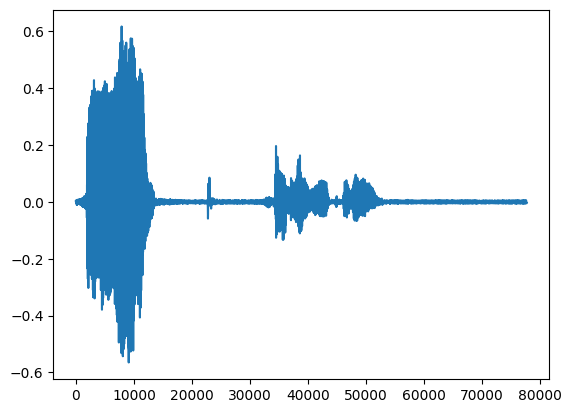

In [37]:
plt.plot(audio_out['audio'])

In [41]:
from IPython.display import Audio

In [42]:
Audio(data=audio_out['audio'],rate=audio_out['sampling_rate'])